**# Actividad 5
# Predicción de Cancelación de Reservas Hoteleras**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/hotel_bookings.csv")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [21]:
print("Dimensiones:")
print(df.shape)

print("\nInformación:")
df.info()

display(df.head())

Dimensiones:
(119390, 32)

Información:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


### Interpretación

Se identificaron valores faltantes principalmente en las variables agent, company, country y children. Durante la fase de limpieza estos valores fueron tratados mediante imputación siguiendo reglas de negocio definidas para el proyecto.


In [6]:
df.duplicated().sum()

np.int64(31994)

<Axes: xlabel='is_canceled', ylabel='count'>

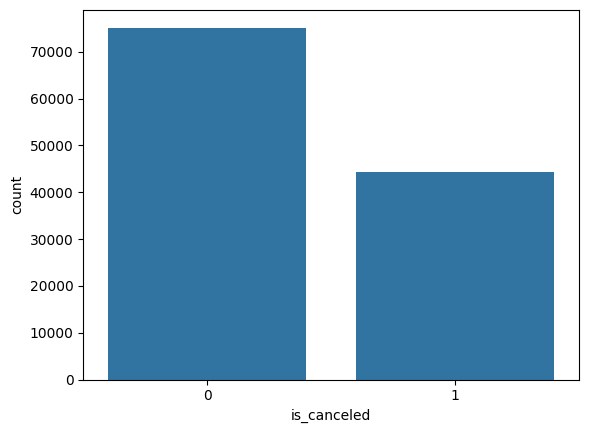

In [7]:
sns.countplot(
    data=df,
    x="is_canceled"
)

<Axes: xlabel='is_canceled', ylabel='lead_time'>

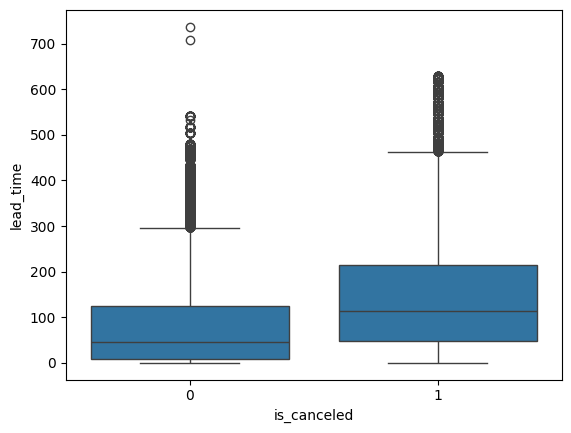

In [8]:
sns.boxplot(
    data=df,
    x="is_canceled",
    y="lead_time"
)

<Axes: xlabel='hotel', ylabel='count'>

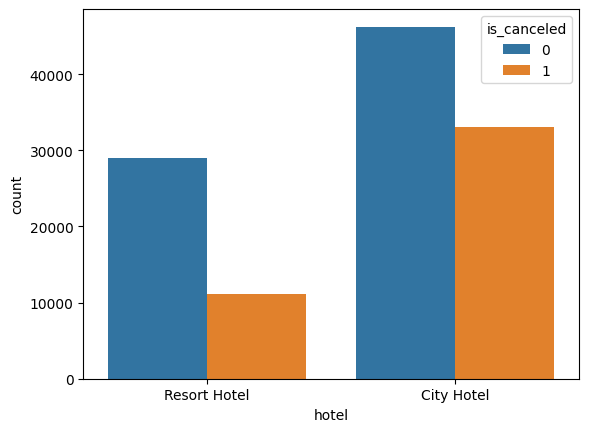

In [9]:
sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled"
)

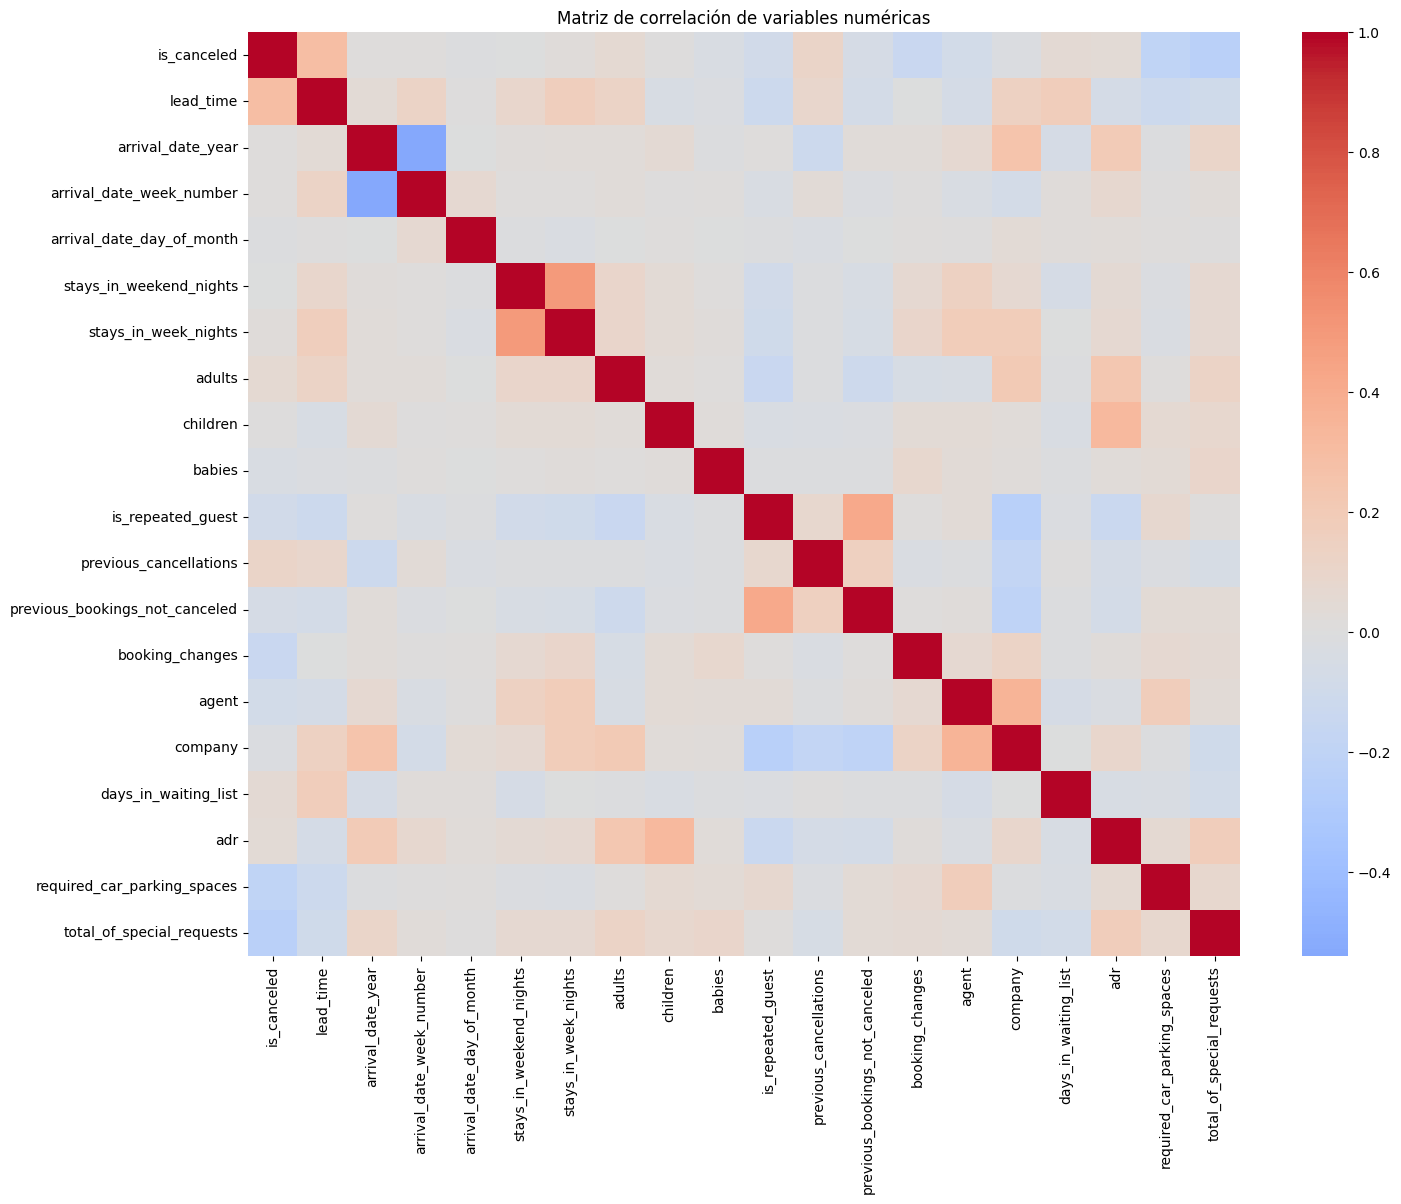

In [22]:
# Seleccionar únicamente variables numéricas
numericas = df.select_dtypes(include=["int64", "float64"])

# Calcular matriz de correlación
corr = numericas.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de variables numéricas")
plt.show()


In [16]:
corr_cancelacion = (
    corr["is_canceled"]
    .sort_values(ascending=False)
)

corr_cancelacion



,is_canceled
is_canceled,1.000000
lead_time,0.293123
previous_cancellations,0.110133
adults,0.060017
days_in_waiting_list,0.054186
adr,0.047557
stays_in_week_nights,0.024765
arrival_date_year,0.016660
arrival_date_week_number,0.008148
children,0.005048


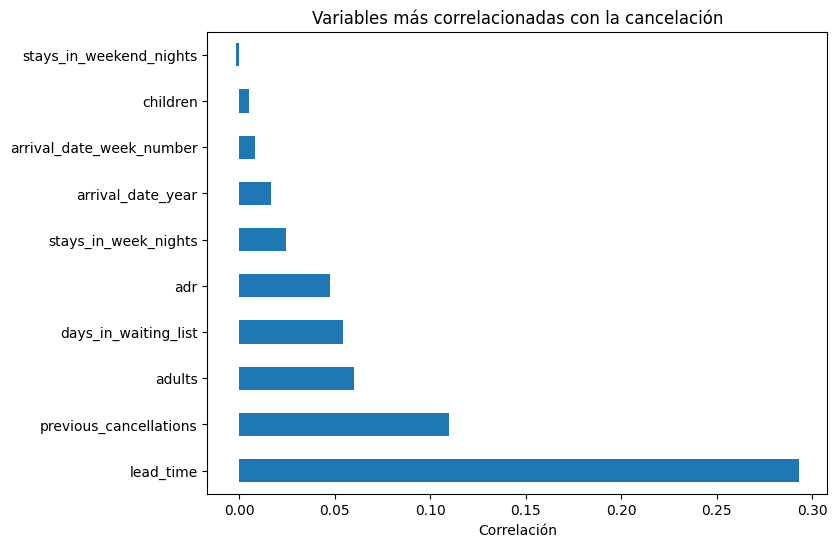

In [17]:
plt.figure(figsize=(8,6))

corr_cancelacion.drop("is_canceled").head(10).plot(
    kind="barh"
)

plt.title("Variables más correlacionadas con la cancelación")
plt.xlabel("Correlación")
plt.show()

In [23]:
resultados = pd.read_csv(
    "/content/drive/MyDrive/resultados_modelos.csv"
)

resultados
resultados.sort_values(
    by="roc_auc",
    ascending=False
)

,Unnamed: 0,accuracy,precision,recall,f1,roc_auc
1,xgboost,0.848963,0.759894,0.659725,0.706276,0.917310
0,random_forest,0.851771,0.785862,0.634319,0.702005,0.914025


<Axes: >

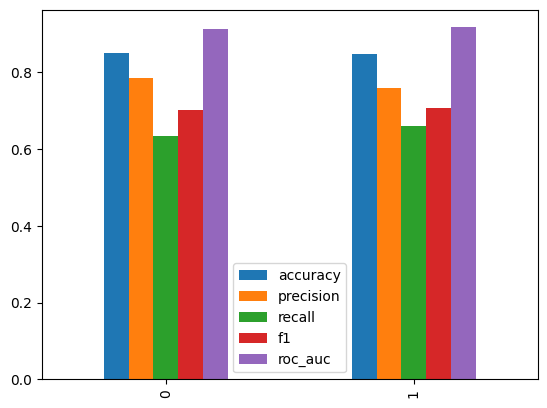

In [20]:
resultados.plot(
    kind="bar"
)

# Conclusiones

Se evaluaron dos algoritmos de clasificación: Random Forest y XGBoost.

Random Forest obtuvo una Accuracy ligeramente superior (85.18%), mientras que XGBoost presentó mejores resultados en Recall, F1 Score y ROC-AUC.

Dado que el objetivo del proyecto es identificar reservas con alta probabilidad de cancelación, se consideró que XGBoost ofrece un mejor equilibrio entre capacidad predictiva y generalización.

Además, XGBoost redujo significativamente el tiempo de entrenamiento respecto a Random Forest, lo que representa una ventaja relevante desde una perspectiva de MLOps y escalabilidad operativa.

Por estas razones, XGBoost fue seleccionado como modelo final del proyecto.